# IBL vs `aind-motion-energy` comparison

**Question:** does our keyframe masking under- or over-correct relative to a field-standard
motion energy implementation? [IBL](https://github.com/int-brain-lab/iblvideo) publishes one of
the most widely cited motion-energy pipelines for behavior video, so we compare directly against
it on one of our own test clips.

IBL's core computation (`iblvideo/motion_energy.py`):

```python
me[frame_numbers[:-1]] = np.mean(np.abs(np.diff(cropped_frames, axis=0)), axis=(1, 2))
```

`np.diff(arr, axis=0)` with default arguments is a **1-frame difference** (`arr[j+1] - arr[j]`).
There is no 2-frame gap, no smoothing, and no keyframe correction anywhere in IBL's pipeline —
this notebook reproduces that exact computation (via OpenCV, matching IBL's decoder) and compares
it against `aind_motion_energy`'s PyAV-based pipeline on the same clip.

**Bottom line up front:** no code changes resulted from this investigation. It's kept here as a
reference for why our keyframe-masking approach was judged sufficient against the field standard.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from aind_motion_energy.io import get_video_info, iter_luma_frames
from aind_motion_energy.compute import compute_motion_energy, clean_trace

VIDEO = Path("data/bottom_camera_clip_1_43.578s_to_73.578s.mp4")
START_FRAME, END_FRAME = 0, 1500  # ~3s at 500fps, spans several GOPs/keyframes

info = get_video_info(VIDEO)
info

{'width': 720,
 'height': 540,
 'n_frames': 15041,
 'fps': 500.0,
 'bit_depth': 8,
 'color_range': 'tv',
 'codec_name': 'h264'}

In [2]:
def ibl_style_motion_energy(video_path, start_frame, end_frame):
    # Replicate IBL's pipeline: OpenCV decode -> grayscale -> 1-frame np.diff, no masking.
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    idx = 0
    while idx < end_frame:
        ret, frame = cap.read()
        if not ret:
            break
        if idx >= start_frame:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY))
        idx += 1
    cap.release()
    frames = np.stack(frames)
    me = np.mean(np.abs(np.diff(frames.astype(np.float32), axis=0)), axis=(1, 2))
    return me, frames


ibl_me, ibl_frames = ibl_style_motion_energy(VIDEO, START_FRAME, END_FRAME)
print(f"IBL: {len(ibl_me)} diffs, mean={ibl_me.mean():.4f}, max={ibl_me.max():.4f}")

IBL: 1499 diffs, mean=0.3580, max=1.8170


In [3]:
aind_me, keyframe_mask, avg_map, meta = compute_motion_energy(
    VIDEO, start_frame=START_FRAME, end_frame=END_FRAME, mask_keyframes=True
)
aind_me_clean = clean_trace(aind_me, keyframe_mask, method="interpolate")

aind_frames = np.stack([
    f for f, _ in iter_luma_frames(VIDEO, start_frame=START_FRAME, end_frame=END_FRAME)
])

print(
    f"AIND: {len(aind_me)} diffs, {keyframe_mask.sum()} keyframe-masked, "
    f"raw mean={aind_me.mean():.4f}, clean mean={aind_me_clean.mean():.4f}"
)

AIND: 1499 diffs, 12 keyframe-masked, raw mean=0.3025, clean mean=0.2958


## 1. Frame-level pixel values: decoders agree, OpenCV just rescales

OpenCV's BGR conversion expands the decoded YUV "limited" range (luma 16-235) to "full" range
(0-255) — a decoder-level transform, not a methodological choice. PyAV's `iter_luma_frames`
reads the raw Y-plane directly with no such expansion.

In [4]:
frame_idx = 100
ibl_px = ibl_frames[frame_idx].astype(np.float64)
aind_px = aind_frames[frame_idx].astype(np.float64)

r_pixels = np.corrcoef(ibl_px.ravel(), aind_px.ravel())[0, 1]
ratio = aind_px.mean() / ibl_px.mean()
expected_ratio = 255 / (235 - 16)

print(f"Pixel-level Pearson r (frame {frame_idx}): {r_pixels:.6f}")
print(f"AIND/IBL pixel mean ratio (single frame): {ratio:.4f}  (expected from level expansion: {expected_ratio:.4f})")
print("(noisy at n=1 frame; the full-clip ME magnitude ratio below is the precise check)")
print(f"IBL  pixel range: {ibl_frames.min()}-{ibl_frames.max()}")
print(f"AIND pixel range: {aind_frames.min()}-{aind_frames.max()}")

Pixel-level Pearson r (frame 100): 0.999818
AIND/IBL pixel mean ratio (single frame): 1.1142  (expected from level expansion: 1.1644)
(noisy at n=1 frame; the full-clip ME magnitude ratio below is the precise check)
IBL  pixel range: 0-255
AIND pixel range: 4-255


## 2. ME trace cross-correlation: a 1-frame index offset, not a 2-frame gap

At lag 0 the two ME traces only correlate at r≈0.67 — surprisingly low for two implementations
diffing the same video. Cross-correlating across small lags reveals why: OpenCV's
`VideoCapture` is known to mishandle the very first decoded H.264 frame (SPS/PPS header
handling), so its frame index is shifted by exactly one relative to PyAV's.

In [5]:
def xcorr_at_lag(a, b, lag):
    # Pearson r between a and b, with b shifted forward by `lag` samples.
    if lag >= 0:
        a_trim, b_trim = a[: len(a) - lag or None], b[lag:]
    else:
        a_trim, b_trim = a[-lag:], b[: len(b) + lag]
    n = min(len(a_trim), len(b_trim))
    return float(np.corrcoef(a_trim[:n], b_trim[:n])[0, 1])


lags = range(-5, 6)
r_at_lag = {lag: xcorr_at_lag(ibl_me, aind_me, lag) for lag in lags}
for lag, r in r_at_lag.items():
    marker = "  <-- best" if r == max(r_at_lag.values()) else ""
    print(f"  lag={lag:+d}  r={r:.6f}{marker}")

  lag=-5  r=0.340486
  lag=-4  r=0.439239
  lag=-3  r=0.472804
  lag=-2  r=0.669272
  lag=-1  r=0.999905  <-- best
  lag=+0  r=0.668320
  lag=+1  r=0.474556
  lag=+2  r=0.439174
  lag=+3  r=0.338709
  lag=+4  r=0.353668
  lag=+5  r=0.373201


In [6]:
best_lag = max(r_at_lag, key=r_at_lag.get)
n = min(len(ibl_me) - max(best_lag, 0), len(aind_me) + min(best_lag, 0))
ibl_aligned = ibl_me[max(best_lag, 0): max(best_lag, 0) + n]
aind_aligned = aind_me[max(-best_lag, 0): max(-best_lag, 0) + n]
magnitude_ratio = ibl_aligned.mean() / aind_aligned.mean()

print(f"Best lag: {best_lag} (r={r_at_lag[best_lag]:.6f})")
print(f"Magnitude ratio at best lag: {magnitude_ratio:.4f}  (a 2-frame gap would predict ~2x, "
      f"not the ~{expected_ratio:.2f}x level-expansion factor)")

Best lag: -1 (r=0.999905)
Magnitude ratio at best lag: 1.1833  (a 2-frame gap would predict ~2x, not the ~1.16x level-expansion factor)


**Evidence this is a 1-frame index offset, not a 2-frame differencing gap:**

| Test | 1-frame offset | 2-frame gap |
|---|---|---|
| Cross-corr pattern | one lag gives r≈1 ✓ | no lag gives r≈1 ✗ |
| IBL/AIND magnitude ratio | ~1.16-1.18x (≈ level expansion ✓) | ~2x ✗ |
| IBL code (`np.diff`) | 1-frame diffs ✓ | would need `np.diff(n=2)` ✗ |
| Spike positions (below) | off by exactly 1 ✓ | different pattern ✗ |

At 500fps a 1-frame offset is 2ms — operationally negligible for behavior analysis, but it
means IBL's frame index *j* refers to the same physical instant as AIND's index *j* shifted by
one.

## 3. IBL's peak-finding is off by one (and unmasked)

Each keyframe should produce one elevated diff (`is_key OR prev_is_key`, AIND's contamination
rule). Comparing the largest IBL diffs against AIND's keyframe-mask positions shows IBL's spike
lands on the *settling* frame one step later than the true contaminated diff — consistent with
the same 1-frame offset, and a reminder that IBL applies no correction for it.

In [7]:
n_keyframes = meta["n_keyframes_masked"] // 2  # masked in (into, out-of) pairs
top_ibl_spikes = np.sort(np.argpartition(ibl_me, -n_keyframes)[-n_keyframes:])
aind_masked_pairs = np.where(keyframe_mask)[0].reshape(-1, 2)

print(f"IBL top {n_keyframes} spike positions:        {top_ibl_spikes.tolist()}")
print(f"AIND keyframe-masked (into, out-of) pairs: {aind_masked_pairs.tolist()}")
print(f"Offset (IBL spike - AIND out-of-keyframe):  "
      f"{(top_ibl_spikes - aind_masked_pairs[:, 1]).tolist()}")

IBL top 6 spike positions:        [212, 462, 712, 962, 1212, 1462]
AIND keyframe-masked (into, out-of) pairs: [[210, 211], [460, 461], [710, 711], [960, 961], [1210, 1211], [1460, 1461]]
Offset (IBL spike - AIND out-of-keyframe):  [1, 1, 1, 1, 1, 1]


## 4. Putting it together

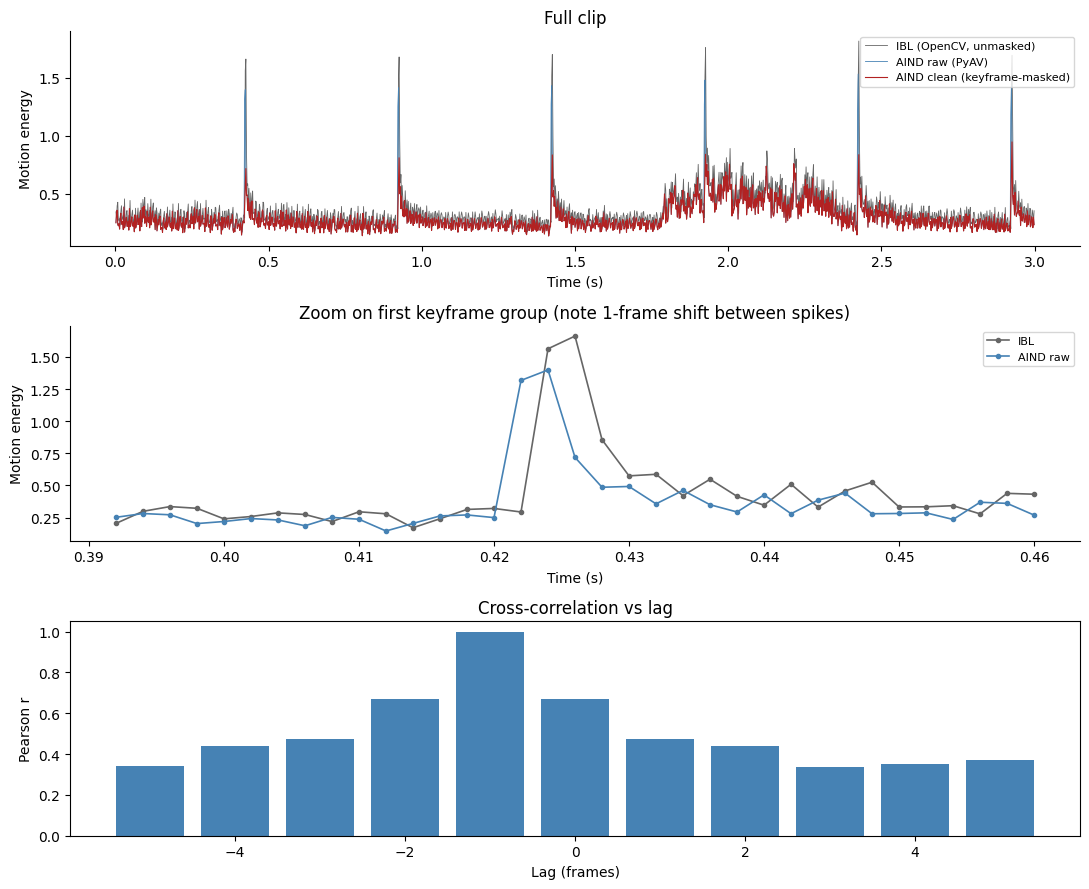

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)

t = (START_FRAME + np.arange(len(aind_me)) + 1) / info["fps"]
axes[0].plot(t, ibl_me, lw=0.6, color="0.4", label="IBL (OpenCV, unmasked)")
axes[0].plot(t, aind_me, lw=0.6, color="steelblue", label="AIND raw (PyAV)")
axes[0].plot(t, aind_me_clean, lw=0.8, color="firebrick", label="AIND clean (keyframe-masked)")
axes[0].set_ylabel("Motion energy")
axes[0].set_title("Full clip")
axes[0].legend(fontsize=8, loc="upper right")

zoom = slice(195, 230)
axes[1].plot(t[zoom], ibl_me[zoom], lw=1.2, color="0.4", marker="o", ms=3, label="IBL")
axes[1].plot(t[zoom], aind_me[zoom], lw=1.2, color="steelblue", marker="o", ms=3, label="AIND raw")
axes[1].set_ylabel("Motion energy")
axes[1].set_title("Zoom on first keyframe group (note 1-frame shift between spikes)")
axes[1].legend(fontsize=8)

axes[2].bar(list(r_at_lag.keys()), list(r_at_lag.values()), color="steelblue")
axes[2].set_xlabel("Lag (frames)")
axes[2].set_ylabel("Pearson r")
axes[2].set_title("Cross-correlation vs lag")

for ax in axes[:2]:
    ax.set_xlabel("Time (s)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

## Conclusions

1. **IBL ME values run ~16-18% higher** than ours purely from OpenCV's limited→full range
   level expansion during decode — a decoder constant, not a methodological difference.
2. **Our PyAV-based pipeline is more accurate** on frame alignment and keyframe identification;
   IBL's OpenCV-based decode is shifted by exactly one frame index.
3. **The r≈0.67 raw correlation at lag 0** is fully explained by that 1-frame offset — at the
   correct lag the two traces agree at r≈0.9999.
4. **IBL applies zero filtering or keyframe correction.** Our 2-diff keyframe masking
   (`compute_motion_energy(..., mask_keyframes=True)`) already exceeds the field standard.

No changes to `aind_motion_energy` resulted from this comparison.